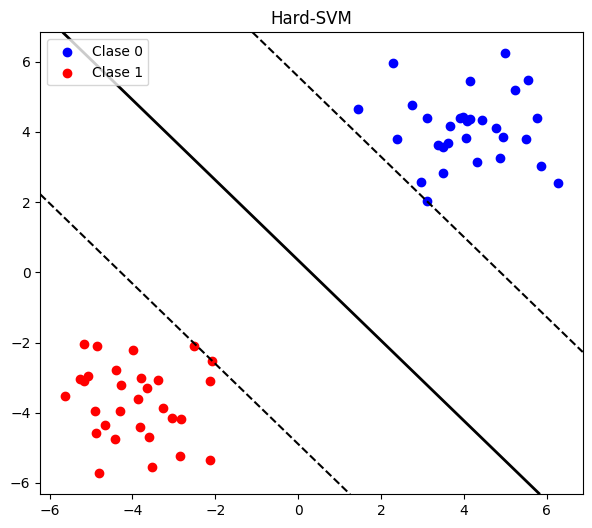

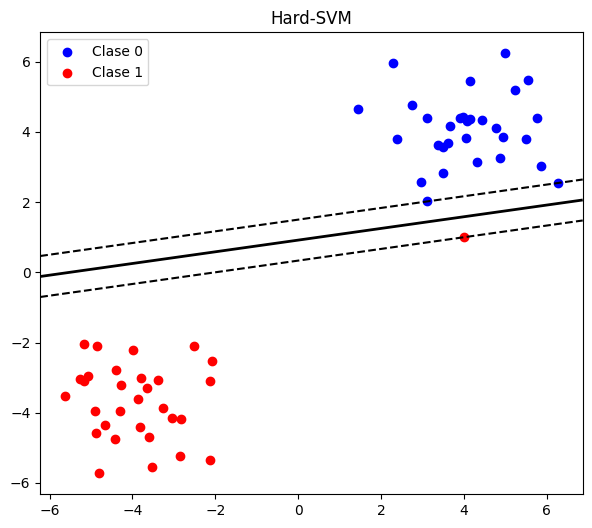

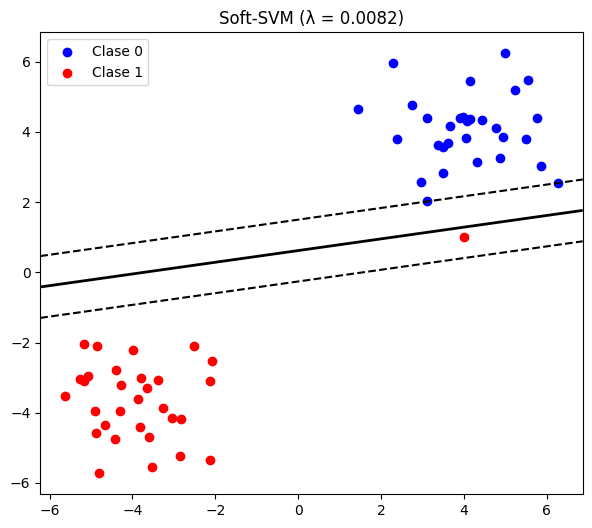

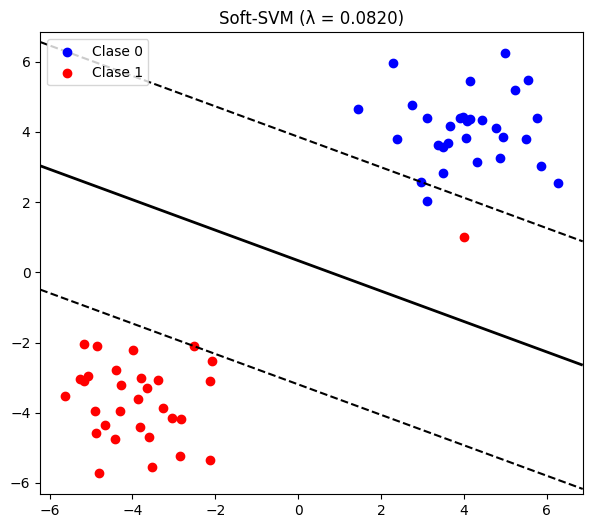

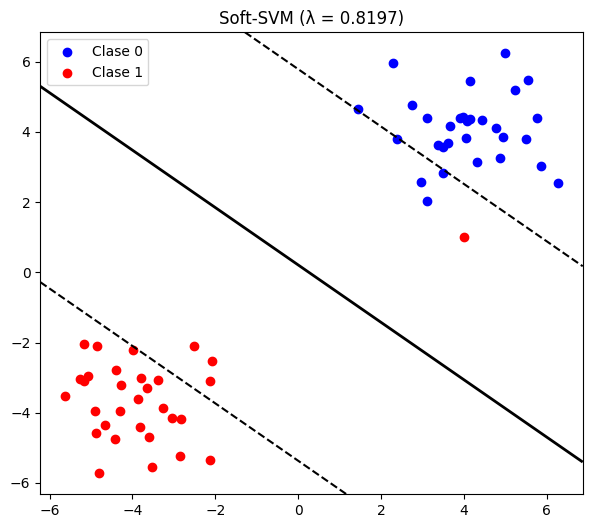

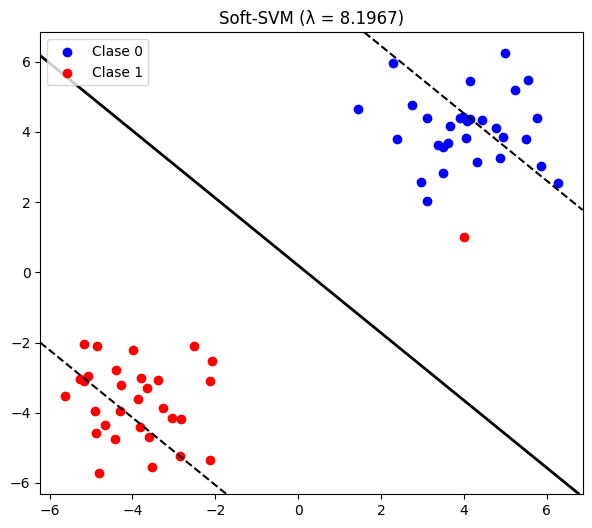

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# -------------------------------------------------------
# 1. Generar datos linealmente separables sin outlier
# -------------------------------------------------------
np.random.seed(0)

# Clase azul (y=0)
X_blue = np.random.randn(30, 2) + np.array([4, 4])

# Clase roja (y=1)
X_red = np.random.randn(30, 2) + np.array([-4, -4])

X = np.vstack([X_blue, X_red])
y = np.array([0]*30 + [1]*30)

# -------------------------------------------------------
# 2. Entrenar Hard-SVM sin outlier
# -------------------------------------------------------
hard_no_outlier = SVC(kernel='linear', C=1e10)
hard_no_outlier.fit(X, y)

# -------------------------------------------------------
# 3. Crear outlier rojo cerca de los azules
# -------------------------------------------------------
outlier = np.array([[4, 1]])  # muy cerca del cluster azul

X_with_outlier = np.vstack([X, outlier])
y_with_outlier = np.append(y, 1)

# -------------------------------------------------------
# 4. Hard-SVM con outlier
# -------------------------------------------------------
hard_with_outlier = SVC(kernel='linear', C=1e10)
hard_with_outlier.fit(X_with_outlier, y_with_outlier)

# -------------------------------------------------------
# 5. Soft-SVM con varios valores de C
# -------------------------------------------------------
C_values = [1, 0.1, 0.01, 0.001]
soft_models = []

m = len(X_with_outlier)  # número total de muestras (61)

for C in C_values:
    model = SVC(kernel='linear', C=C)
    model.fit(X_with_outlier, y_with_outlier)
    
    # Convertir C a lambda 
    lam = 1 / (2 * C * m)
    
    soft_models.append((lam, model))

# -------------------------------------------------------
# 6. Función para dibujar fronteras
# -------------------------------------------------------
def plot_svm(model, X, y, title):
    plt.figure(figsize=(7, 6))
    plt.scatter(X[y==0, 0], X[y==0, 1], c='blue', label='Clase 0')
    plt.scatter(X[y==1, 0], X[y==1, 1], c='red', label='Clase 1')


    ax = plt.gca() #get current axes
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx) 
    xy = np.vstack([XX.ravel(), YY.ravel()]).T 
    Z = model.decision_function(xy).reshape(XX.shape) 

    # Curvas de nivel para dibujar el hiperplano y los margenes
    ax.contour(XX, YY, Z, colors='k', levels=[0], linewidths=2)
    ax.contour(XX, YY, Z, colors='k', levels=[-1, 1], linestyles=['--', '--'])

    plt.title(title)
    plt.legend()
    plt.show()

# -------------------------------------------------------
# 7. Dibujar Hard-SVM sin outlier y con outlier
# -------------------------------------------------------
plot_svm(hard_no_outlier, X, y, "Hard-SVM")
plot_svm(hard_with_outlier, X_with_outlier, y_with_outlier, 
         "Hard-SVM")

# -------------------------------------------------------
# 8. Dibujar Soft-SVM para varios valores de λ
# -------------------------------------------------------
for lam, model in soft_models:
    plot_svm(model, X_with_outlier, y_with_outlier,
             f"Soft-SVM (λ = {lam:.4f})")